In [15]:
import requests
import pandas as pd

CLIENT_ID = "6280552700be408aa61daaa22a8de46b"
CLIENT_SECRET = "8f2bbec07ec7418d9e07ac0bf5309eea"

auth_response = requests.post("https://accounts.spotify.com/api/token", {
    "grant_type": "client_credentials",
    "client_id": CLIENT_ID,
    "client_secret": CLIENT_SECRET,
})

access_token = auth_response.json()["access_token"]
print("Token acquired:", access_token[:10], "...")

Token acquired: BQD9uwP1Fd ...


In [16]:
url = "https://api.spotify.com/v1/search"
params = {"q": "pop", "type": "track", "limit": 10}
r = requests.get(url, headers=headers, params=params)
print(r.status_code)
data = r.json()
print(json.dumps(data, indent=2)[:1500])

200
{
  "tracks": {
    "href": "https://api.spotify.com/v1/search?offset=0&limit=10&query=pop&type=track",
    "limit": 10,
    "next": "https://api.spotify.com/v1/search?offset=10&limit=10&query=pop&type=track",
    "offset": 0,
    "previous": null,
    "total": 13,
    "items": [
      {
        "album": {
          "album_type": "single",
          "artists": [
            {
              "external_urls": {
                "spotify": "https://open.spotify.com/artist/1Xyo4u8uXC1ZmMpatF05PJ"
              },
              "href": "https://api.spotify.com/v1/artists/1Xyo4u8uXC1ZmMpatF05PJ",
              "id": "1Xyo4u8uXC1ZmMpatF05PJ",
              "name": "The Weeknd",
              "type": "artist",
              "uri": "spotify:artist:1Xyo4u8uXC1ZmMpatF05PJ"
            },
            {
              "external_urls": {
                "spotify": "https://open.spotify.com/artist/6tbjWDEIzxoDsBA1FuhfPW"
              },
              "href": "https://api.spotify.com/v1/artists/6tbj

In [21]:
r = requests.get("https://api.spotify.com/v1/search", headers=headers, params={"q": "pop", "type": "track", "limit": 10})
data = r.json()
item = data["tracks"]["items"][0]
print(list(item.keys()))

['album', 'artists', 'disc_number', 'duration_ms', 'explicit', 'external_ids', 'external_urls', 'href', 'id', 'is_local', 'is_playable', 'name', 'track_number', 'type', 'uri']


In [22]:
print(list(item["album"].keys()))
print(list(item["artists"][0].keys()))

['album_type', 'artists', 'external_urls', 'href', 'id', 'images', 'is_playable', 'name', 'release_date', 'release_date_precision', 'total_tracks', 'type', 'uri']
['external_urls', 'href', 'id', 'name', 'type', 'uri']


In [23]:
import time

genres = ["pop", "hip hop", "country", "rock", "electronic"]
all_tracks = []

for genre in genres:
    url = "https://api.spotify.com/v1/search"
    params = {"q": genre, "type": "track", "limit": 10}
    r = requests.get(url, headers=headers, params=params)
    if r.status_code != 200:
        print(f"ERROR for {genre}: {r.status_code} - {r.json()}")
        continue
    data = r.json()
    for item in data["tracks"]["items"]:
        all_tracks.append({
            "track_name": item["name"],
            "artist": item["artists"][0]["name"],
            "search_term": genre,
            "explicit": item["explicit"],
            "duration_ms": item["duration_ms"],
            "release_date": item["album"]["release_date"]
        })
    time.sleep(0.5)

df = pd.DataFrame(all_tracks)
df["duration_sec"] = df["duration_ms"] / 1000
print(df.shape)
df.to_csv("spotify_tracks.csv", index=False)
df.head()

(50, 7)


,track_name,artist,search_term,explicit,duration_ms,release_date,duration_sec
0,Popular (with Playboi Carti & Madonna) - From ...,The Weeknd,pop,True,215466,2023-06-02,215.466
1,Pop Off Pop Off,KiiiKiii,pop,False,141285,2026-08-10,141.285
2,POP DAT THANG,DaBaby,pop,True,138251,2026-01-23,138.251
3,Pop Out (feat. Lil Tjay),Polo G,pop,True,166560,2019-06-07,166.560
4,"POP DAT THANG (feat. GloRilla, Yung Miami & YK...",DaBaby,pop,True,235106,2026-05-01,235.106


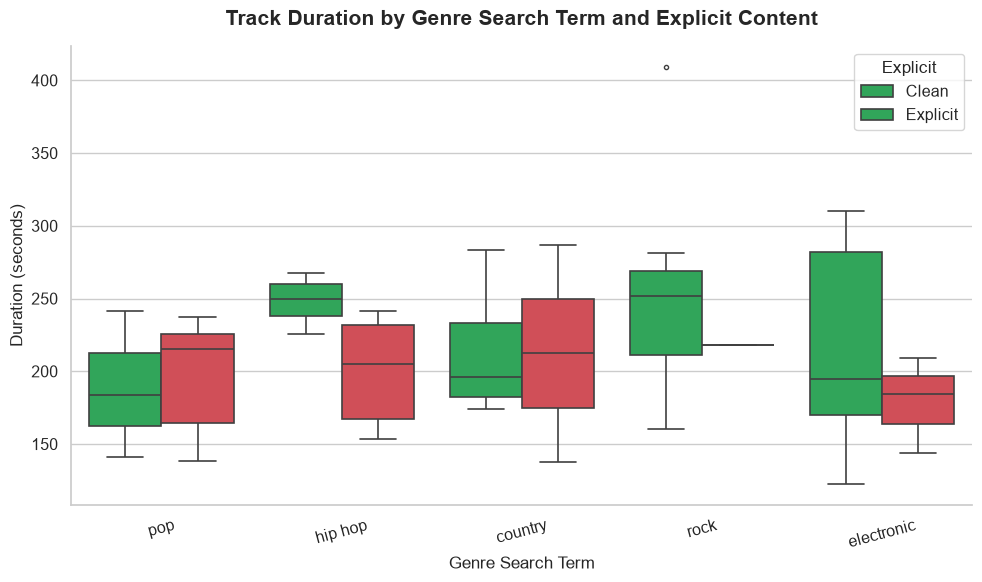

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", font_scale=1.05)
palette = {True: "#E63946", False: "#1DB954"}  # red = explicit, Spotify green = clean

plt.figure(figsize=(10,6))
ax = sns.boxplot(
    data=df, x="search_term", y="duration_sec", hue="explicit",
    palette=palette, linewidth=1.2, fliersize=3
)
ax.set_title("Track Duration by Genre Search Term and Explicit Content", fontsize=15, fontweight="bold", pad=15)
ax.set_xlabel("Genre Search Term", fontsize=12)
ax.set_ylabel("Duration (seconds)", fontsize=12)
plt.xticks(rotation=15)
plt.legend(title="Explicit", labels=["Clean", "Explicit"], loc="upper right", frameon=True)
sns.despine()
plt.tight_layout()
plt.savefig("viz1.png", dpi=200, bbox_inches="tight")
plt.show()

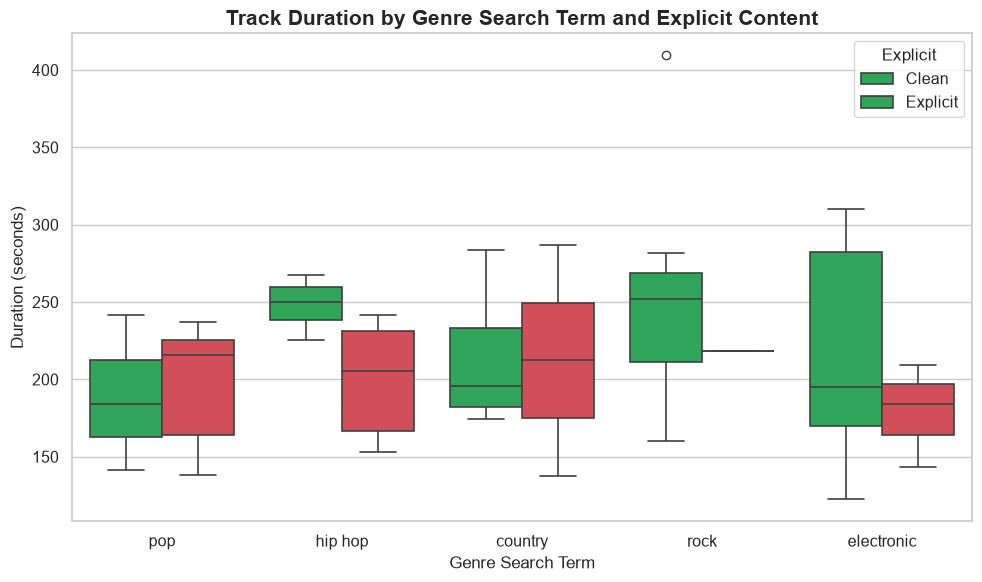

In [27]:
sns.set_theme(style="whitegrid", font_scale=1.05)
palette = {True: "#E63946", False: "#1DB954"}

plt.figure(figsize=(10,6))
ax = sns.boxplot(data=df, x="search_term", y="duration_sec", hue="explicit", palette=palette, linewidth=1.2)
ax.set_title("Track Duration by Genre Search Term and Explicit Content", fontsize=15, fontweight="bold")
ax.set_xlabel("Genre Search Term")
ax.set_ylabel("Duration (seconds)")
plt.legend(title="Explicit", labels=["Clean", "Explicit"])
plt.tight_layout()
plt.savefig("viz1.png", dpi=200)
plt.show()

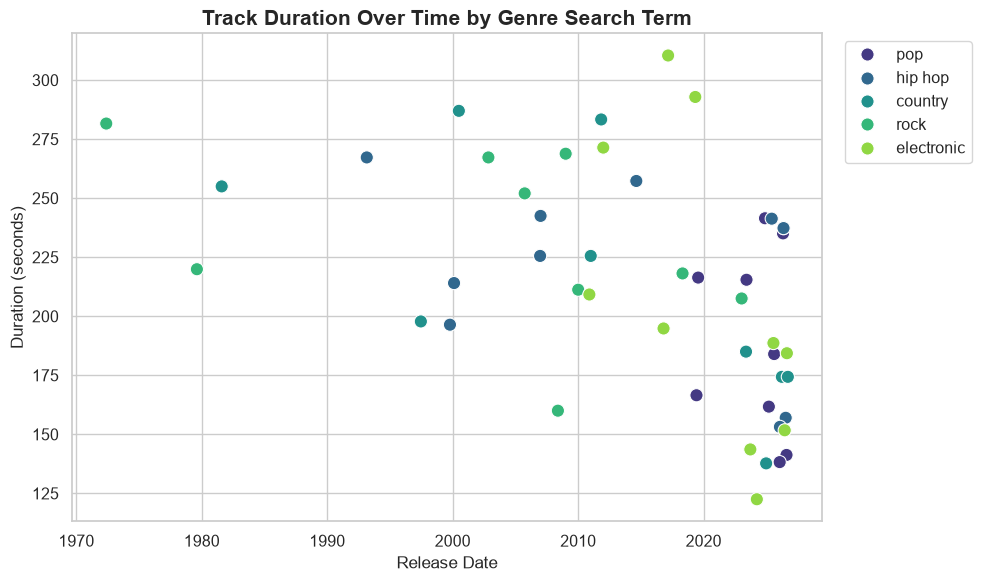

In [28]:
df["release_date_parsed"] = pd.to_datetime(df["release_date"], errors="coerce")

plt.figure(figsize=(10,6))
ax = sns.scatterplot(data=df, x="release_date_parsed", y="duration_sec", hue="search_term", palette="viridis", s=90)
ax.set_title("Track Duration Over Time by Genre Search Term", fontsize=15, fontweight="bold")
ax.set_xlabel("Release Date")
ax.set_ylabel("Duration (seconds)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("viz2.png", dpi=200)
plt.show()